# Mackenzie River Outflow SSS and day of sea ice formation

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
from scipy.stats import t
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:38759")
client

<Client: 'tcp://127.0.0.1:38759' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

# open RHOAnoma zarr store - [fraction of sea ice, 0 to 1]
RHOAnoma_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 to since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

# add reference density to density anomaly (RHOAnoma)
rhoConst = 1027.5 # reference density
density_day = RHOAnoma_zarr_day.RHOAnoma.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1) + rhoConst

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

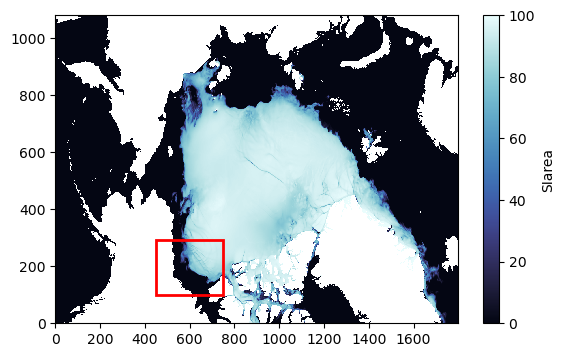

In [9]:
import matplotlib.patches as patches
fig, ax1 = plt.subplots(1,1,figsize=[6.5,4])
ice_day.sel(time='2020-09-20').isel(time=0).plot(ax=ax1,cmap=cmocean.cm.ice,vmin=0,vmax=100);
ax1.set_title("")
ax1.set_ylabel("")
ax1.set_xlabel("");

# Create a Rectangle patch and add the patch to the Axes
rect = patches.Rectangle((450, 100), 300, 190, linewidth=2, edgecolor='r', linestyle='solid', facecolor='none') # xy, width, height
ax1.add_patch(rect);

In [13]:
# cut out beaufort sea box
SSS_beaufort = salt_day.isel(k=0,i=slice(450,750),j=slice(100,290))
SST_beaufort = theta_day.isel(k=0,i=slice(450,750),j=slice(100,290))
SI_beaufort = ice_day.isel(i=slice(450,750),j=slice(100,290))
rho_beaufort = density_day.isel(i=slice(450,750),j=slice(100,290))
land_beaufort_mask = HH_grid_land.isel(i=slice(450,750),j=slice(100,290))

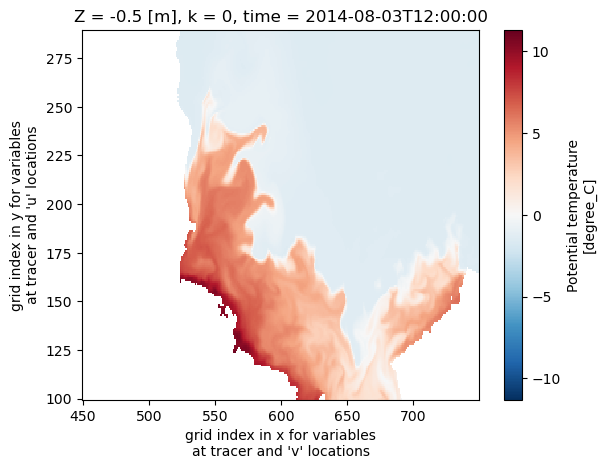

In [14]:
SST_beaufort.isel(time=200).plot();

### Calculate delta rho

In [15]:
print(rho_beaufort.isel(k=0).Z.values)
print(rho_beaufort.isel(k=10).Z.values)
print(rho_beaufort.isel(k=21).Z.values)

-0.5
-21.125
-99.37


In [16]:
# calculate delta rho
delta_rho20 = rho_beaufort.isel(k=10) - rho_beaufort.isel(k=0)
delta_rho100 = rho_beaufort.isel(k=21) - rho_beaufort.isel(k=0)

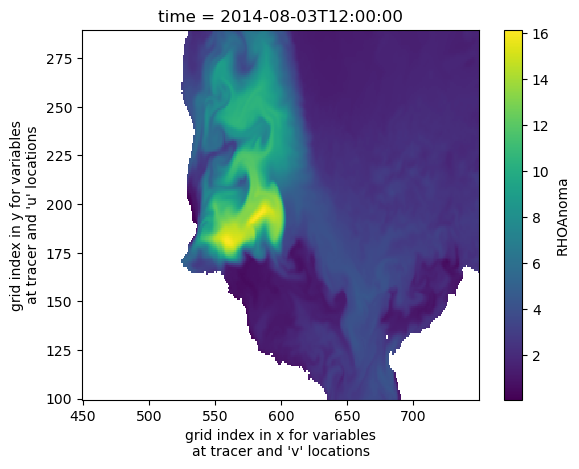

In [17]:
# select only Beaufort region
delta_rho20.isel(time=200).plot();

### Plot variables within selected box

In [18]:
# rotate 90 degrees counterclockwise
si_flip = xr.DataArray(np.rot90((SI_beaufort.sel(time='2020-09-15').isel(time=0)),3,axes=[0,1]), dims=['i','j'])
land_mask_flip = xr.DataArray(np.rot90(land_beaufort_mask,3,axes=[0,1]), dims=['i','j'])

# temp
temp_beaufort_flip = xr.DataArray(np.rot90(SST_beaufort.sel(time='2020-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# salinity
salt_beaufort_flip = xr.DataArray(np.rot90(SSS_beaufort.sel(time='2020-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# delta rho
delta_rho20_flip = xr.DataArray(np.rot90(delta_rho20.sel(time='2020-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])
delta_rho100_flip = xr.DataArray(np.rot90(delta_rho100.sel(time='2020-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

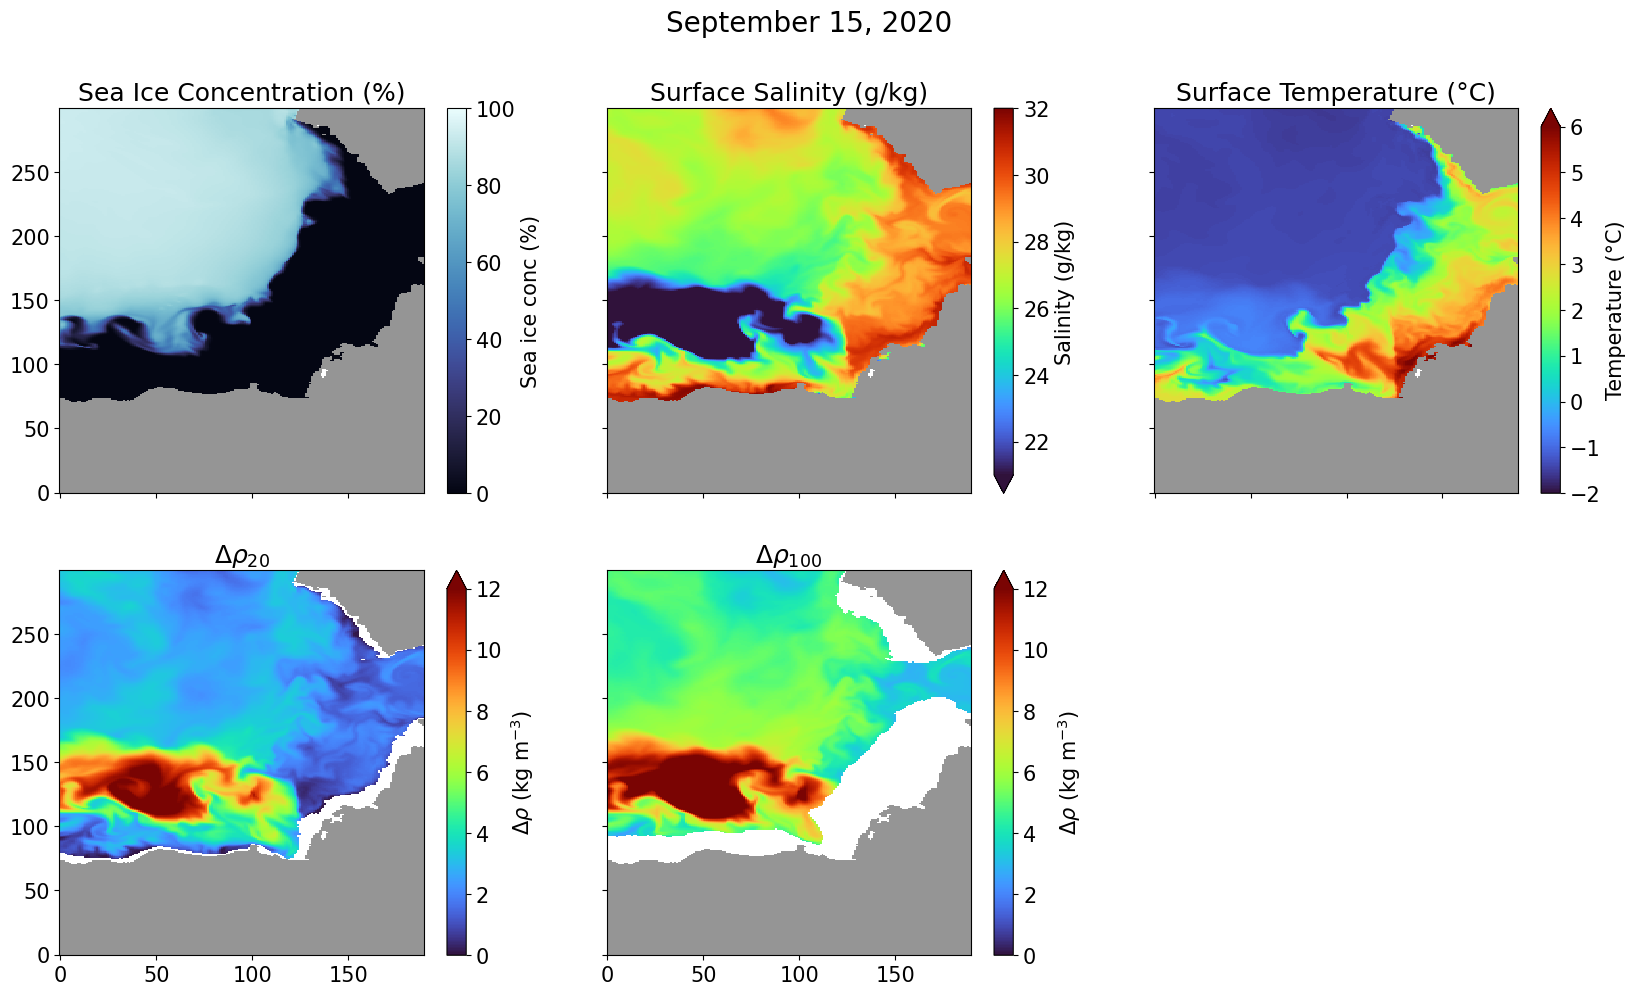

In [19]:
plt.rcParams.update({'font.size': 15})
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,figsize=[20,11],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,vmin=0,vmax=100,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_beaufort_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
temp_beaufort_flip.plot(ax=ax3,cmap='turbo',vmin=-2,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});
delta_rho20_flip.plot(ax=ax4,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});
delta_rho100_flip.plot(ax=ax5,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});

# salt_beaufort_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');
# beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot.contour(ax=ax3,levels=[6.5],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3,ax4,ax5):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("")
    ax.set_xlabel("")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");
ax4.set_title(r"$\Delta\rho_{20}$");
ax5.set_title(r"$\Delta\rho_{100}$");

ax6.set_axis_off()

plt.suptitle("September 15, 2020",y=0.97,fontsize=20);

Mask out sea ice for each day, then compute correlation coefficients between SSS and delta rho for each day and plot time series

### Mask out SI for each day

In [20]:
# check shape of vars
print(SSS_beaufort.shape)
print(SST_beaufort.shape)
print(delta_rho20.shape)
print(delta_rho100.shape)

(2543, 190, 300)
(2543, 190, 300)
(2543, 190, 300)
(2543, 190, 300)


2020 example

In [21]:
# select just one year of data
SSS_2020 = SSS_beaufort.sel(time="2020")
SST_2020 = SST_beaufort.sel(time="2020")
SI_2020 = SI_beaufort.sel(time="2020")
delta_rho20_2020 = delta_rho20.sel(time="2020")
delta_rho100_2020 = delta_rho100.sel(time="2020")

In [22]:
# mask grid cells with >15% ice cover
SSS_2020_icefree = SSS_2020.where(SI_2020<15)
SST_2020_icefree = SST_2020.where(SI_2020<15)
delta_rho20_2020_icefree = delta_rho20_2020.where(SI_2020<15)
delta_rho100_2020_icefree = delta_rho100_2020.where(SI_2020<15)

In [23]:
# rotate 90 degrees counterclockwise
si_flip = xr.DataArray(np.rot90((SI_2020.sel(time='2020-09-15').isel(time=0)),3,axes=[0,1]), dims=['i','j'])
land_mask_flip = xr.DataArray(np.rot90(land_beaufort_mask,3,axes=[0,1]), dims=['i','j'])

# temp
temp_beaufort_flip = xr.DataArray(np.rot90(SST_2020_icefree.sel(time='2020-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# salinity
salt_beaufort_flip = xr.DataArray(np.rot90(SSS_2020_icefree.sel(time='2020-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# delta rho
delta_rho20_flip = xr.DataArray(np.rot90(delta_rho20_2020_icefree.sel(time='2020-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])
delta_rho100_flip = xr.DataArray(np.rot90(delta_rho100_2020_icefree.sel(time='2020-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

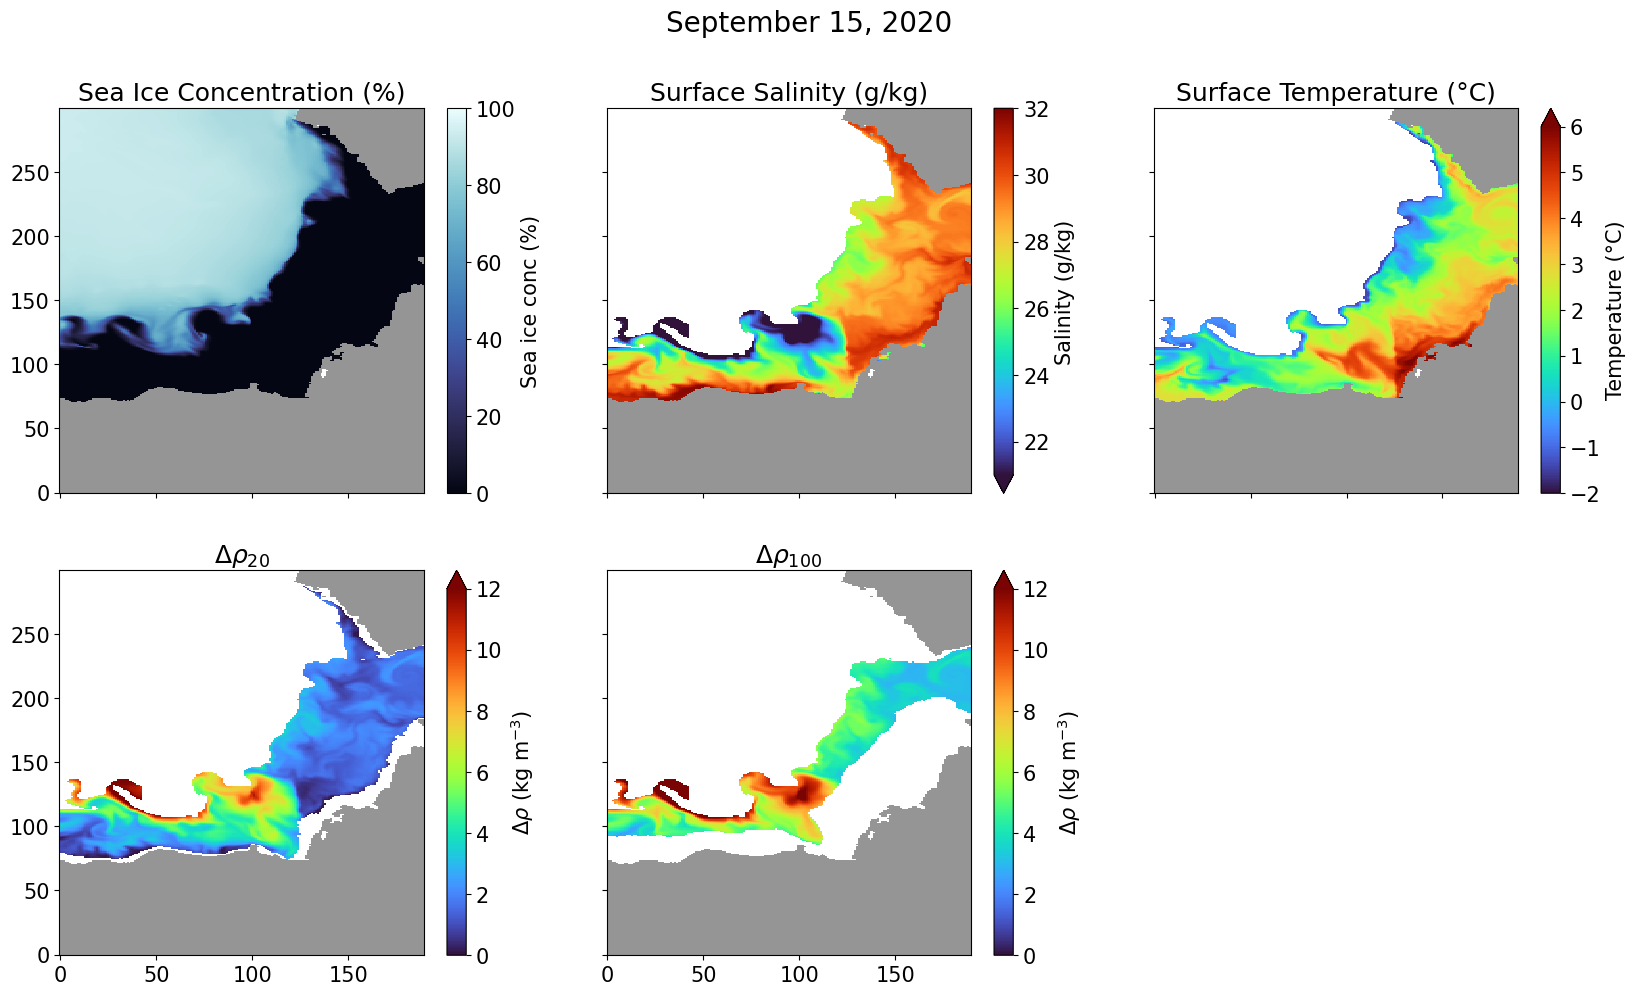

In [24]:
plt.rcParams.update({'font.size': 15})
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,figsize=[20,11],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,vmin=0,vmax=100,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_beaufort_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
temp_beaufort_flip.plot(ax=ax3,cmap='turbo',vmin=-2,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});
delta_rho20_flip.plot(ax=ax4,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});
delta_rho100_flip.plot(ax=ax5,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});

# salt_beaufort_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');
# beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot.contour(ax=ax3,levels=[6.5],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3,ax4,ax5):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("")
    ax.set_xlabel("")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");
ax4.set_title(r"$\Delta\rho_{20}$");
ax5.set_title(r"$\Delta\rho_{100}$");

ax6.set_axis_off()

plt.suptitle("September 15, 2020",y=0.97,fontsize=20);

2019 example

In [25]:
# select just one year of data
SSS_2019 = SSS_beaufort.sel(time="2019")
SST_2019 = SST_beaufort.sel(time="2019")
SI_2019 = SI_beaufort.sel(time="2019")
delta_rho20_2019 = delta_rho20.sel(time="2019")
delta_rho100_2019 = delta_rho100.sel(time="2019")

In [26]:
# mask grid cells with >15% ice cover
SSS_2019_icefree = SSS_2019.where(SI_2019<15)
SST_2019_icefree = SST_2019.where(SI_2019<15)
delta_rho20_2019_icefree = delta_rho20_2019.where(SI_2019<15)
delta_rho100_2019_icefree = delta_rho100_2019.where(SI_2019<15)

In [27]:
# rotate 90 degrees counterclockwise
si_flip = xr.DataArray(np.rot90((SI_2019.sel(time='2019-09-15').isel(time=0)),3,axes=[0,1]), dims=['i','j'])
land_mask_flip = xr.DataArray(np.rot90(land_beaufort_mask,3,axes=[0,1]), dims=['i','j'])

# temp
temp_beaufort_flip = xr.DataArray(np.rot90(SST_2019_icefree.sel(time='2019-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# salinity
salt_beaufort_flip = xr.DataArray(np.rot90(SSS_2019_icefree.sel(time='2019-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# delta rho
delta_rho20_flip = xr.DataArray(np.rot90(delta_rho20_2019_icefree.sel(time='2019-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])
delta_rho100_flip = xr.DataArray(np.rot90(delta_rho100_2019_icefree.sel(time='2019-09-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

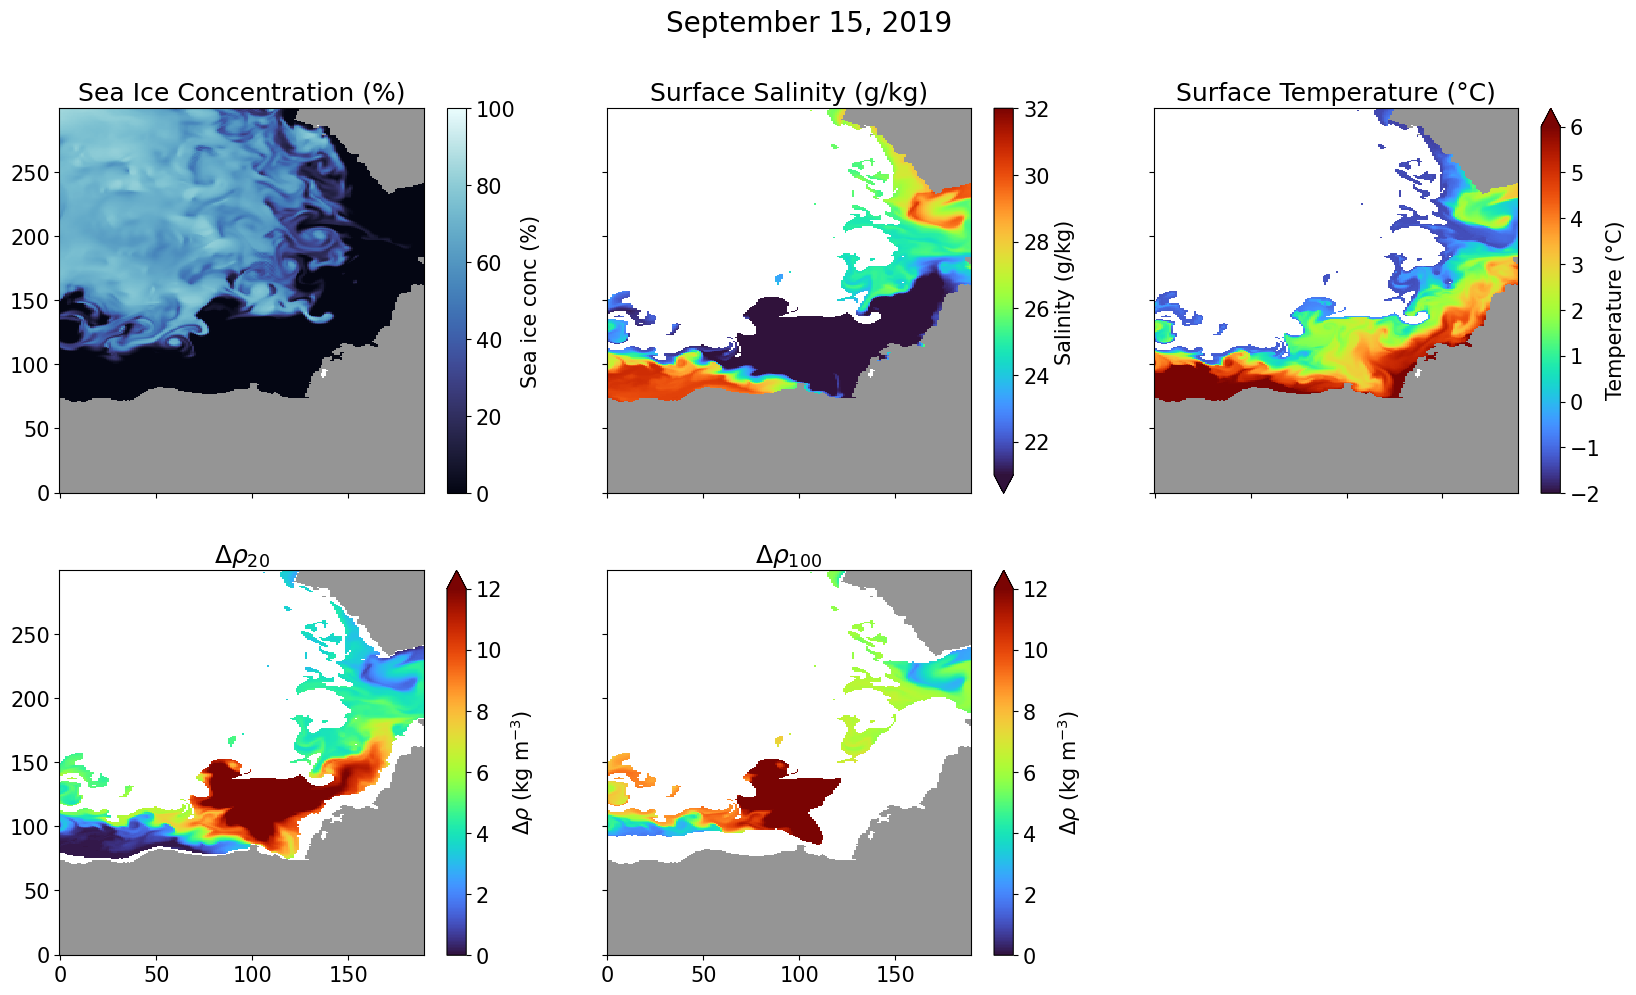

In [28]:
plt.rcParams.update({'font.size': 15})
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,figsize=[20,11],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,vmin=0,vmax=100,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_beaufort_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
temp_beaufort_flip.plot(ax=ax3,cmap='turbo',vmin=-2,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});
delta_rho20_flip.plot(ax=ax4,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});
delta_rho100_flip.plot(ax=ax5,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});

# salt_beaufort_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');
# beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot.contour(ax=ax3,levels=[6.5],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3,ax4,ax5):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("")
    ax.set_xlabel("")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");
ax4.set_title(r"$\Delta\rho_{20}$");
ax5.set_title(r"$\Delta\rho_{100}$");

ax6.set_axis_off()

plt.suptitle("September 15, 2019",y=0.97,fontsize=20);

In [29]:
# calculate SI cover for the beaufort sea box
# select grid cell area
beaufort_area = HH_grid.rAc.isel(i=slice(450,750),j=slice(100,290)).load()
beaufort_area_total_ocean = (beaufort_area*HH_grid.hFacC.isel(k=0,i=slice(450,750),j=slice(100,290))).sum(dim=['j','i']).load()

# calculate sea ice area
SIcover_beaufort_percent = (SI_beaufort*beaufort_area).sum(dim=['j','i']) / beaufort_area_total_ocean

# fix two empty days from the dataset
SIcover_beaufort_percent.loc['2014-04-24'] = np.nan
SIcover_beaufort_percent.loc['2015-04-09'] = np.nan

### Plot SSS and sea ice cover (%) for 7 years

In [30]:
# mask grid cells with >15% ice cover
SSS_icefree = SSS_beaufort.where(SI_beaufort<15)
SST_icefree = SST_beaufort.where(SI_beaufort<15)
delta_rho20_icefree = delta_rho20.where(SI_beaufort<15)
delta_rho100_icefree = delta_rho100.where(SI_beaufort<15)

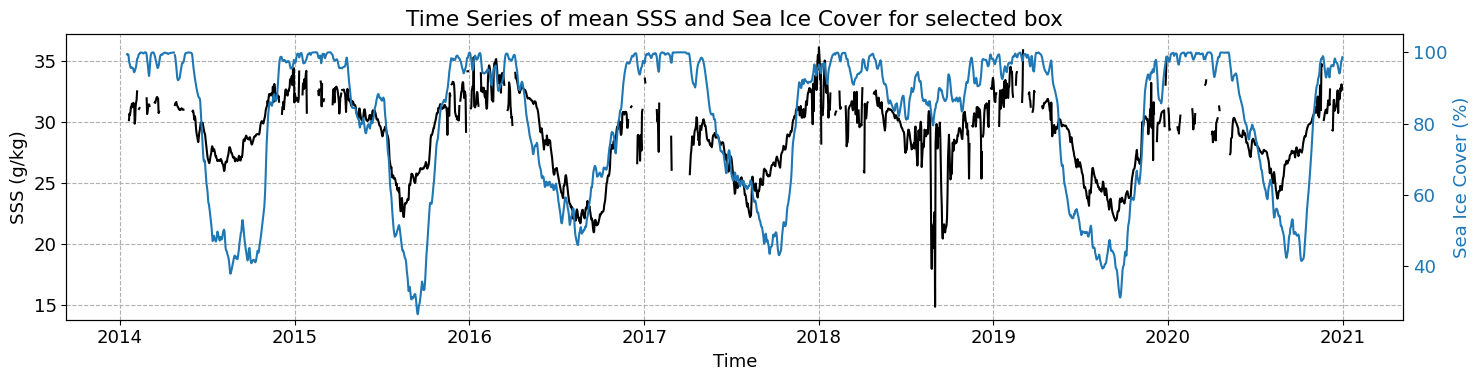

In [31]:
# Create a plot of coeff and sea ice cover
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(15, 4))

# Plot correlation coefficients on the primary axis
# corr_20minus0.plot(ax=ax1, color='k', linestyle='solid', label='Correlation Coefficients', linewidth=1.5)
SSS_icefree.mean(dim=['i','j']).plot(ax=ax1,color='k', linewidth=1.5)
ax1.set_xlabel('Time')
ax1.set_ylabel('SSS (g/kg)', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(linestyle='dashed')

# Create secondary axis for sea ice area
ax2 = ax1.twinx()  # Create a second y-axis
SIcover_beaufort_percent.plot(ax=ax2, color='tab:blue', label='Sea Ice Cover (%)', linewidth=1.5)
ax2.set_ylabel('Sea Ice Cover (%)', color='tab:blue')
ax2.set_ylim(25,105)
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Add a title and show the plot
ax1.set_title(r'Time Series of mean SSS and Sea Ice Cover for selected box')
ax2.set_title("")
fig.tight_layout()

### Isolate SSS, SST on September 15 and DOY for sea ice formation

SSS

In [32]:
# select SSS on September 15 of each year
SSS_sep15 = SSS_icefree.sel(time=SSS_icefree['time'].dt.strftime('%m-%d') == '09-15')

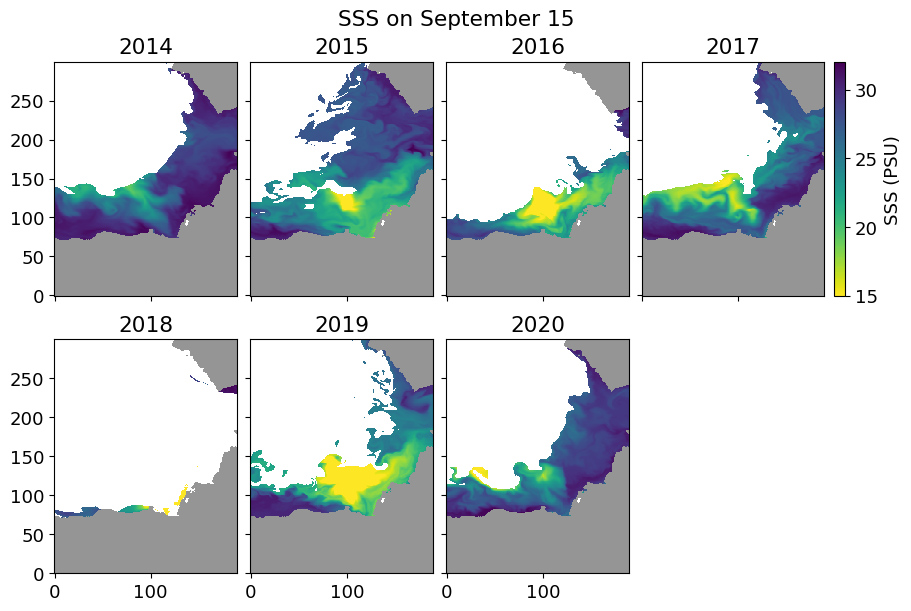

In [33]:
# get global vmin and vmax for consistent color mapping
vmin = 15
vmax = 32

# set up the figure and subplots
fig, axes = plt.subplots(2, 4, figsize=(9, 6), sharex=True, sharey=True, layout='constrained')
axes = axes.ravel()

# plot each month's mean as a subplot
for year in range(0, 7):
    ax = axes[year]
    SSS_flip = xr.DataArray(np.rot90(SSS_sep15.isel(time=year),3,axes=[0,1]), dims=['i','j'])
    im = SSS_flip.plot(
        ax=ax, 
        cmap='viridis_r', 
        vmin=vmin, 
        vmax=vmax, 
        add_colorbar=False
    )
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(str(SSS_sep15.isel(time=year).time.dt.year.values))
    
# add a colorbar for the 4th subplot only
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=vmin, vmax=vmax)),
    ax=axes[3],  # the 3rd subplot
    location='right'
)
cbar.ax.set_ylabel('SSS (PSU)')

axes[7].set_axis_off()

# add a title
plt.suptitle('SSS on September 15')
plt.show()

SST

In [34]:
# select SSS on September 15 of each year
SST_sep15 = SST_icefree.sel(time=SST_icefree['time'].dt.strftime('%m-%d') == '09-15')

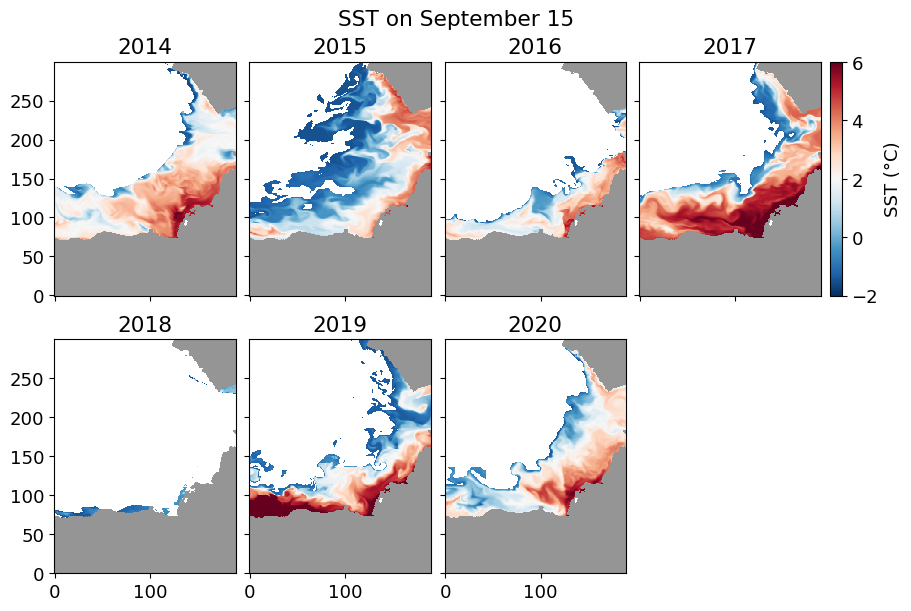

In [35]:
# get global vmin and vmax for consistent color mapping
vmin = -2
vmax = 6

# set up the figure and subplots
fig, axes = plt.subplots(2, 4, figsize=(9, 6), sharex=True, sharey=True, layout='constrained')
axes = axes.ravel()

# plot each month's mean as a subplot
for year in range(0, 7):
    ax = axes[year]
    SST_flip = xr.DataArray(np.rot90(SST_sep15.isel(time=year),3,axes=[0,1]), dims=['i','j'])
    im = SST_flip.plot(
        ax=ax, 
        cmap='RdBu_r', 
        vmin=vmin, 
        vmax=vmax, 
        add_colorbar=False
    )
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(str(SST_sep15.isel(time=year).time.dt.year.values))
    
# add a colorbar for the 4th subplot only
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin, vmax=vmax)),
    ax=axes[3],  # the 3rd subplot
    location='right'
)
cbar.ax.set_ylabel('SST (°C)')

axes[7].set_axis_off()

# add a title
plt.suptitle('SST on September 15')
plt.show()

Isolate DOY

In [36]:
SI_beaufort = SI_beaufort.assign_coords(DOY=SI_beaufort['time'].dt.dayofyear)

In [37]:
# only select months later than september
# sic_fall = SI_beaufort.where(SI_beaufort['time.month'] >= 9, drop=True)
# sic_fall = SI_beaufort.where(SI_beaufort['time.month'] >= 10, drop=True)
sic_fall = SI_beaufort.where(
    (SI_beaufort['time.month'] > 9) | 
    ((SI_beaufort['time.month'] == 9) & (SI_beaufort['time.day'] > 15)), drop=True)

In [38]:
threshold = 15

In [39]:
# Group by year
results = []
for year, group in sic_fall.groupby('time.year'):
    # Subset the DOY variable for the current year
    doy_year = sic_fall.DOY.sel(time=group.time)
    
    # Create a mask for when the concentration exceeds the threshold
    threshold_mask = group >= threshold
    
    # Find the first time index where the mask is True for each grid cell
    first_time_index = threshold_mask.argmax(dim="time")
    
    # Mask out grid cells where SIconc>15% on Sept 15
    # Use masked SSS dataset to do this
    SSS_sep15_yr = SSS_sep15.sel(time=str(year)).rename({"time":"year"})
    all_false_mask = SSS_sep15_yr.isnull()
    first_time_index_clean = first_time_index.where(~all_false_mask, other=np.nan).compute()

    # Use the indices to find the corresponding DOY
    first_doy = doy_year.isel(time=first_time_index_clean.fillna(0).astype(int))
    first_doy = xr.where(all_false_mask, np.nan, first_doy)  # Set invalid cells to NaN

    # Add year as a dimension for later concatenation
    # first_doy = first_doy.expand_dims(year=[year])
    results.append(first_doy)

# Combine the results across years
threshold_dates = xr.concat(results, dim="year")

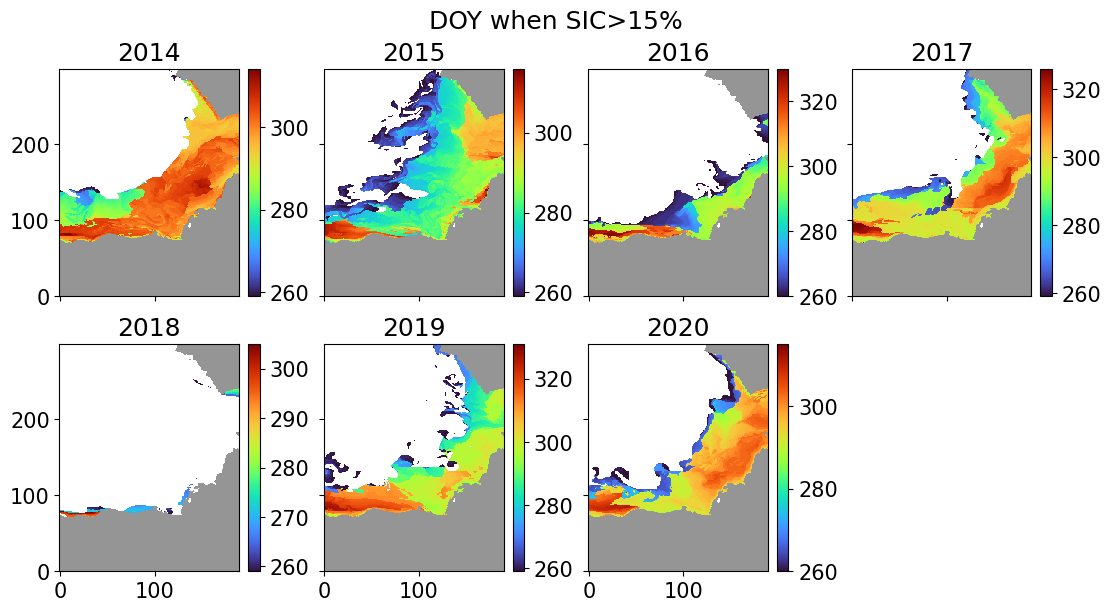

In [31]:
# get global vmin and vmax for consistent color mapping
vmin = 250
vmax = 320

# set up the figure and subplots
fig, axes = plt.subplots(2, 4, figsize=(11, 6), sharex=True, sharey=True, layout='constrained')
axes = axes.ravel()

# plot each month's mean as a subplot
for year in range(0, 7):
    ax = axes[year]
    threshold_dates_flip = xr.DataArray(np.rot90(threshold_dates.isel(year=year),3,axes=[0,1]), dims=['i','j'])
    im = threshold_dates_flip.plot(
        ax=ax, 
        cmap='turbo', 
        # vmin=vmin, 
        # vmax=vmax, 
        # add_colorbar=False
    )
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(str(threshold_dates.isel(year=year,i=0,j=0).time.dt.year.values))
    
# # add a colorbar for the 4th subplot only
# cbar = fig.colorbar(
#     plt.cm.ScalarMappable(cmap='turbo', norm=plt.Normalize(vmin=vmin, vmax=vmax)),
#     ax=axes[3],  # the 3rd subplot
#     location='right'
# )
cbar.ax.set_ylabel('SSS (PSU)')

axes[7].set_axis_off()

# add a title
plt.suptitle('DOY when SIC>15%')
plt.show()

### Consolidate plots into one

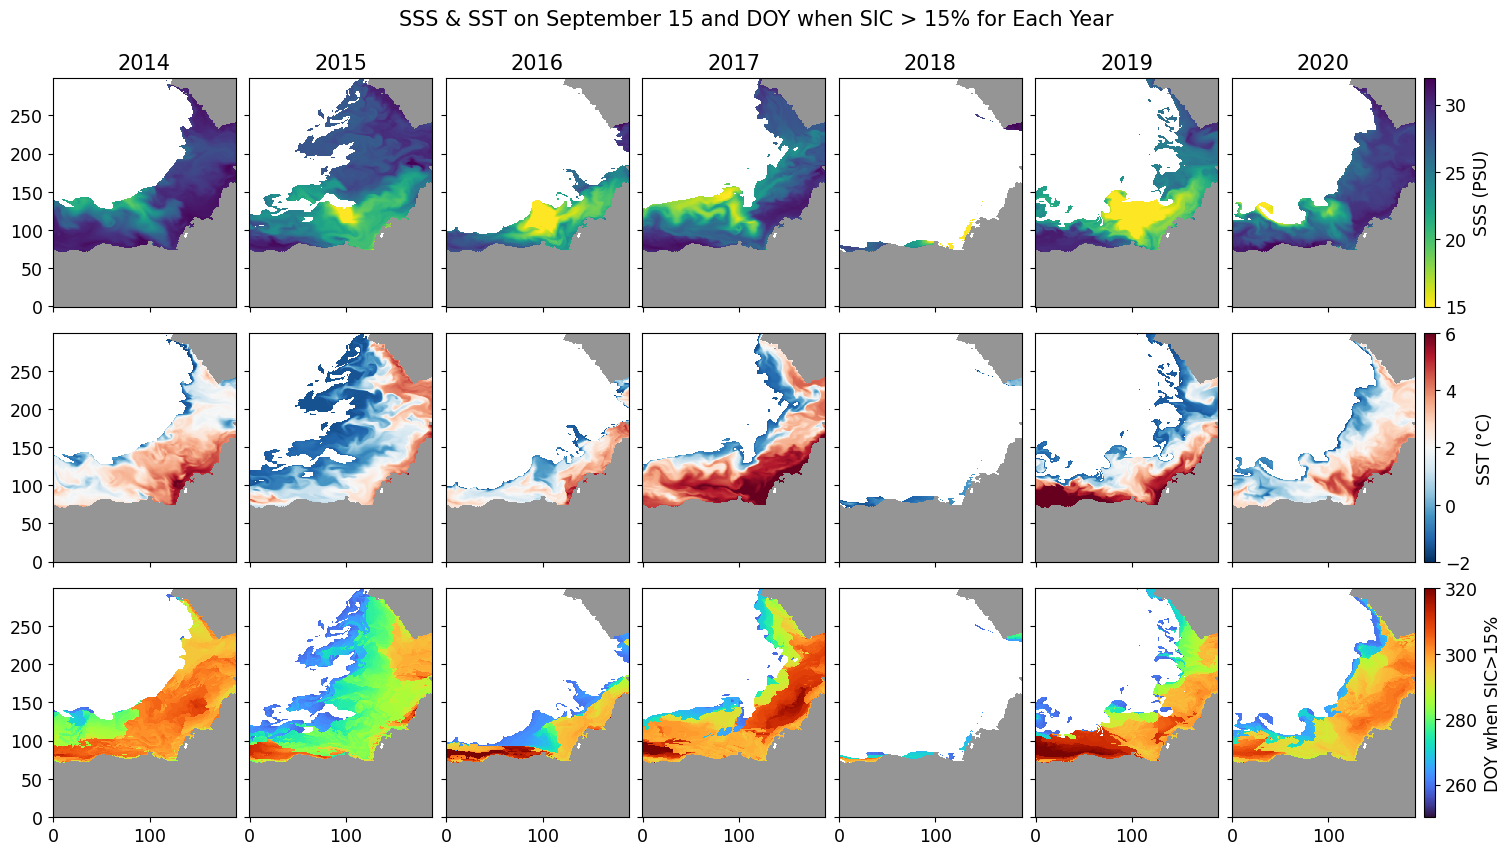

In [229]:
# Set up the figure and subplots (3 rows, 7 columns)
fig, axes = plt.subplots(3, 7, figsize=(15, 8), sharex=True, sharey=True, layout='constrained')
axes = axes.ravel()

# Define the colormap and range for each dataset
vmin_SSS = 15
vmax_SSS = 32
vmin_SST = -2
vmax_SST = 6
vmin_DOY = 250
vmax_DOY = 320

# Plot SSS on September 15 (Row 1)
for year in range(0, 7):
    ax = axes[year]
    SSS_flip = xr.DataArray(np.rot90(SSS_sep15.isel(time=year), 3, axes=[0, 1]), dims=['i', 'j'])
    SSS_flip.plot(ax=ax, cmap='viridis_r', vmin=vmin_SSS, vmax=vmax_SSS, add_colorbar=False)
    land_mask_flip.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(str(SSS_sep15.isel(time=year).time.dt.year.values))

# Add a colorbar for SSS (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=vmin_SSS, vmax=vmax_SSS)),
    ax=axes[6],  # Last subplot of the first row
    location='right'
)
cbar.ax.set_ylabel('SSS (PSU)')

# Plot SST on September 15 (Row 2)
for year in range(0, 7):
    ax = axes[year + 7]  # Offset by 7 for the second row
    SST_flip = xr.DataArray(np.rot90(SST_sep15.isel(time=year), 3, axes=[0, 1]), dims=['i', 'j'])
    SST_flip.plot(ax=ax, cmap='RdBu_r', vmin=vmin_SST, vmax=vmax_SST, add_colorbar=False)
    land_mask_flip.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_title(str(SST_sep15.isel(time=year).time.dt.year.values))
    ax.set_title("")

# Add a colorbar for SST (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin_SST, vmax=vmax_SST)),
    ax=axes[13],  # Last subplot of the second row
    location='right'
)
cbar.ax.set_ylabel('SST (°C)')

# Plot DOY when SIC > 15% (Row 3)
for year in range(0, 7):
    ax = axes[year + 14]  # Offset by 14 for the third row
    threshold_dates_flip = xr.DataArray(np.rot90(threshold_dates.isel(year=year), 3, axes=[0, 1]), dims=['i', 'j'])
    threshold_dates_flip.plot(ax=ax, cmap='turbo', vmin=vmin_DOY, vmax=vmax_DOY, add_colorbar=False)
    land_mask_flip.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_title(str(threshold_dates.isel(year=year, i=0, j=0).time.dt.year.values))
    ax.set_title("")

# Add a colorbar for DOY (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='turbo', norm=plt.Normalize(vmin=vmin_DOY, vmax=vmax_DOY)),
    ax=axes[20],  # Last subplot of the third row
    location='right'
)
cbar.ax.set_ylabel('DOY when SIC>15%')

# Add a title for the whole figure
plt.suptitle('SSS & SST on September 15 and DOY when SIC > 15% for Each Year', fontsize=15,y=1.05);

Plot correlation between Sept 15 SSS and DOY when SI>15%

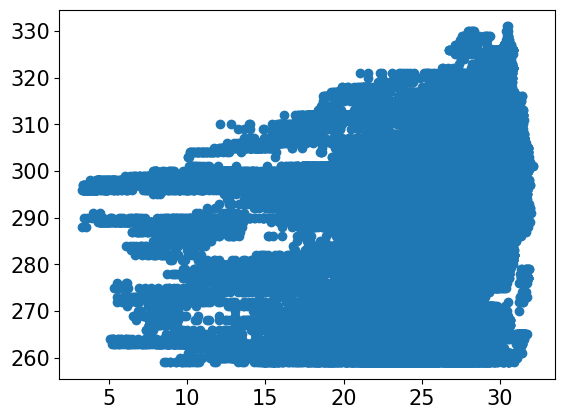

In [40]:
plt.scatter(SSS_sep15.values,threshold_dates.values)

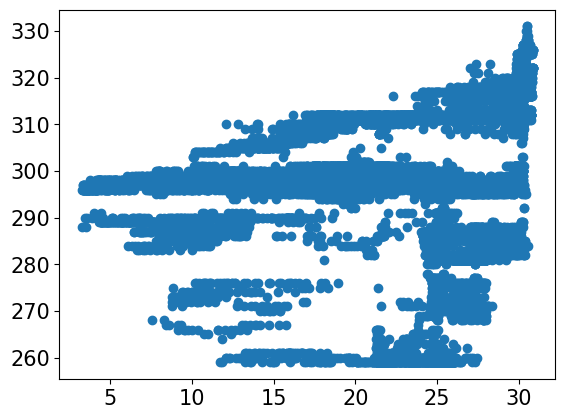

In [39]:
i_year = 5
DOY = threshold_dates.isel(year=i_year)
SSS = SSS_sep15.isel(time=i_year)
plt.scatter(SSS.values,DOY.values)

### Look at DOY when T approaches -1.8C and on that day see what SSS it has.
### But do profiles with lower SSS lose heat faster and have cooler SST sooner?

Can we use SST and then on days when SST approaches freezing, we can see what SSS is and predict where ice will form?

### Plot time series of SST, SSS, and SIconc

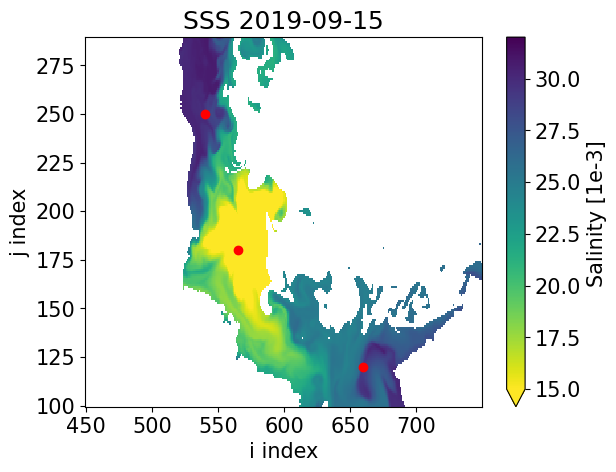

In [75]:
SSS_icefree.sel(time='2019-09-15').plot(cmap='viridis_r',vmin=15,vmax=32);
plt.title('SSS 2019-09-15');
plt.ylabel('j index')
plt.xlabel('i index');
plt.scatter(565,180,c='r');
plt.scatter(540,250,c='r');
plt.scatter(660,120,c='r');

### with SSS

In [40]:
import numpy as np
from datetime import datetime, timedelta

def doy_to_date(year, doy):
    # Start from the first day of the year
    start_date = datetime(year, 1, 1)
    
    # Add the day of year (DOY - 1 because January 1st is the first day)
    target_date = start_date + timedelta(days=doy - 1)
    
    # Convert the date to numpy datetime64 format
    return np.datetime64(target_date)

# Example usage
# year = 2025
# doy = doy_ice  # Day of Year (for example, the 60th day)
# date = doy_to_date(year, int(doy_ice))
# print(date)

In [41]:
DOY_2019 = threshold_dates.sel(year='2019')

In [42]:
i_select = 540
j_select = 250
sss = SSS_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sst = SST_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sic = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
time = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).time
ice_date = doy_to_date(2019, int(DOY_2019.sel(i=i_select,j=j_select)))

In [216]:
ice_date

numpy.datetime64('2019-11-13T00:00:00.000000')

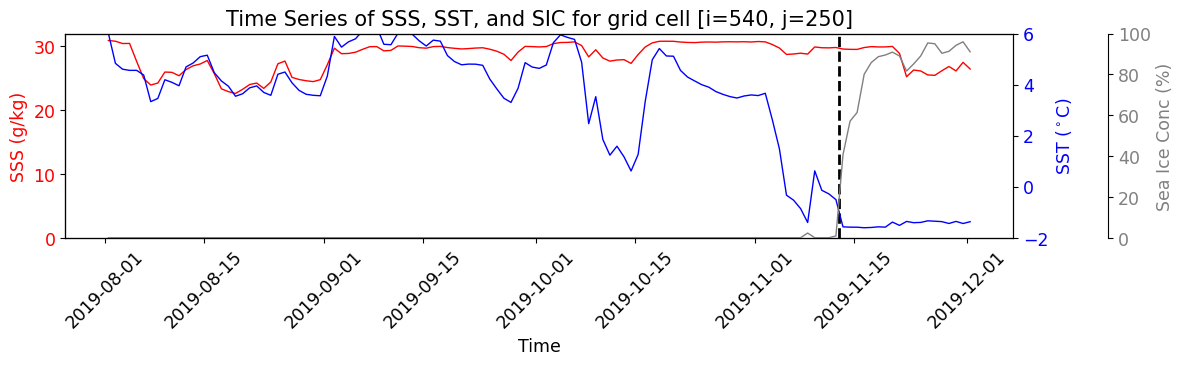

In [194]:
# Create a figure and axis
plt.rcParams.update({'font.size': 12.5})
fig, ax1 = plt.subplots(figsize=(12, 3),sharex=True)

# Plot SSS on the primary y-axis
ax1.plot(time, sss, label="SSS", color="red",linewidth=1)
ax1.set_xlabel("Time")
ax1.set_ylabel("SSS (g/kg)", color="red")
ax1.set_ylim(0,32)
ax1.tick_params(axis='y', labelcolor="red")

# add day when si>15%
ax1.axvline(x=ice_date,linestyle='dashed',linewidth=2,color='k')

# Create the first secondary y-axis for SST
ax2 = ax1.twinx()
ax2.plot(time, sst, label="SST", color="blue",linewidth=1)
ax2.set_ylabel(r"SST ($^\circ$C)", color="blue")
ax2.set_ylim(-2,6)
ax2.tick_params(axis='y', labelcolor="blue")

# Create a second secondary y-axis for SIC
ax3 = ax1.twinx()
ax3.spines["right"].set_position(('axes', 1.1)) # Offset the third y-axis
ax3.plot(time, sic, label="SIC", color="gray",linewidth=1)
ax3.set_ylabel("Sea Ice Conc (%)", color="gray")
ax3.set_ylim(0,100)
ax3.tick_params(axis='y', labelcolor="gray")

# Align the labels of all y-axes
fig.tight_layout()

for label in ax1.get_xticklabels():
    label.set_rotation(45)

# Show the plot
plt.title(f"Time Series of SSS, SST, and SIC for grid cell [i={i_select}, j={j_select}]")
plt.show()

In [217]:
i_select = 565
j_select = 180
sss = SSS_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sst = SST_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sic = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
time = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).time
ice_date = doy_to_date(2019, int(DOY_2019.sel(i=i_select,j=j_select)))

In [218]:
ice_date

numpy.datetime64('2019-10-26T00:00:00.000000')

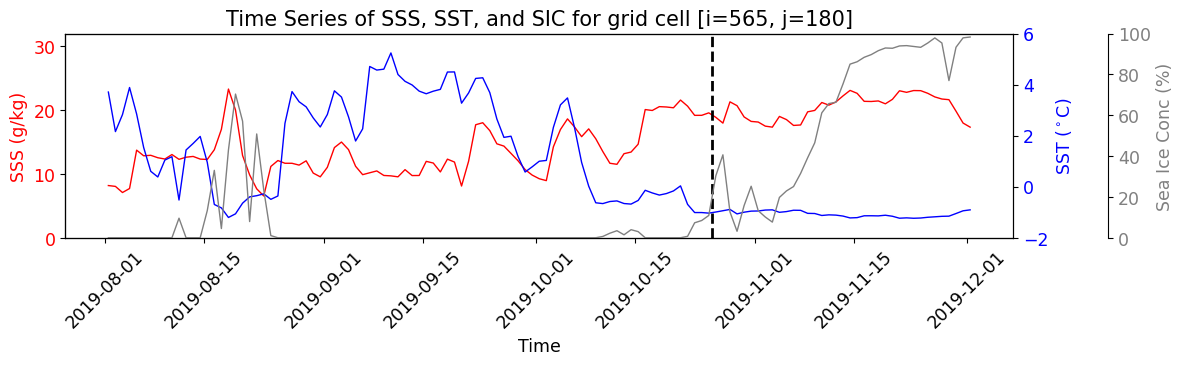

In [196]:
# Create a figure and axis
plt.rcParams.update({'font.size': 12.5})
fig, ax1 = plt.subplots(figsize=(12, 3),sharex=True)

# Plot SSS on the primary y-axis
ax1.plot(time, sss, label="SSS", color="red",linewidth=1)
ax1.set_xlabel("Time")
ax1.set_ylabel("SSS (g/kg)", color="red")
ax1.set_ylim(0,32)
ax1.tick_params(axis='y', labelcolor="red")

# add day when si>15%
ax1.axvline(x=ice_date,linestyle='dashed',linewidth=2,color='k')

# Create the first secondary y-axis for SST
ax2 = ax1.twinx()
ax2.plot(time, sst, label="SST", color="blue",linewidth=1)
ax2.set_ylabel(r"SST ($^\circ$C)", color="blue")
ax2.set_ylim(-2,6)
ax2.tick_params(axis='y', labelcolor="blue")

# Create a second secondary y-axis for SIC
ax3 = ax1.twinx()
ax3.spines["right"].set_position(('axes', 1.1)) # Offset the third y-axis
ax3.plot(time, sic, label="SIC", color="gray",linewidth=1)
ax3.set_ylabel("Sea Ice Conc (%)", color="gray")
ax3.set_ylim(0,100)
ax3.tick_params(axis='y', labelcolor="gray")

# Align the labels of all y-axes
fig.tight_layout()

for label in ax1.get_xticklabels():
    label.set_rotation(45)

# Show the plot
plt.title(f"Time Series of SSS, SST, and SIC for grid cell [i={i_select}, j={j_select}]")
plt.show()

In [219]:
i_select = 660
j_select = 120
sss = SSS_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sst = SST_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sic = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
time = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).time
ice_date = doy_to_date(2019, int(DOY_2019.sel(i=i_select,j=j_select)))

In [220]:
ice_date

numpy.datetime64('2019-10-14T00:00:00.000000')

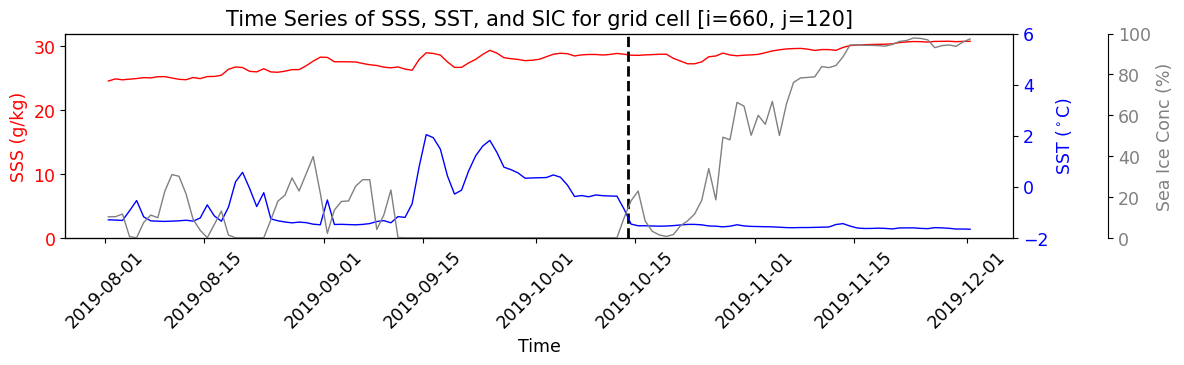

In [198]:
# Create a figure and axis
plt.rcParams.update({'font.size': 12.5})
fig, ax1 = plt.subplots(figsize=(12, 3),sharex=True)

# Plot SSS on the primary y-axis
ax1.plot(time, sss, label="SSS", color="red",linewidth=1)
ax1.set_xlabel("Time")
ax1.set_ylabel("SSS (g/kg)", color="red")
ax1.set_ylim(0,32)
ax1.tick_params(axis='y', labelcolor="red")

# add day when si>15%
ax1.axvline(x=ice_date,linestyle='dashed',linewidth=2,color='k')

# Create the first secondary y-axis for SST
ax2 = ax1.twinx()
ax2.plot(time, sst, label="SST", color="blue",linewidth=1)
ax2.set_ylabel(r"SST ($^\circ$C)", color="blue")
ax2.set_ylim(-2,6)
ax2.tick_params(axis='y', labelcolor="blue")

# Create a second secondary y-axis for SIC
ax3 = ax1.twinx()
ax3.spines["right"].set_position(('axes', 1.1)) # Offset the third y-axis
ax3.plot(time, sic, label="SIC", color="gray",linewidth=1)
ax3.set_ylabel("Sea Ice Conc (%)", color="gray")
ax3.set_ylim(0,100)
ax3.tick_params(axis='y', labelcolor="gray")

# Align the labels of all y-axes
fig.tight_layout()

for label in ax1.get_xticklabels():
    label.set_rotation(45)

# Show the plot
plt.title(f"Time Series of SSS, SST, and SIC for grid cell [i={i_select}, j={j_select}]")
plt.show()

### with delta rho

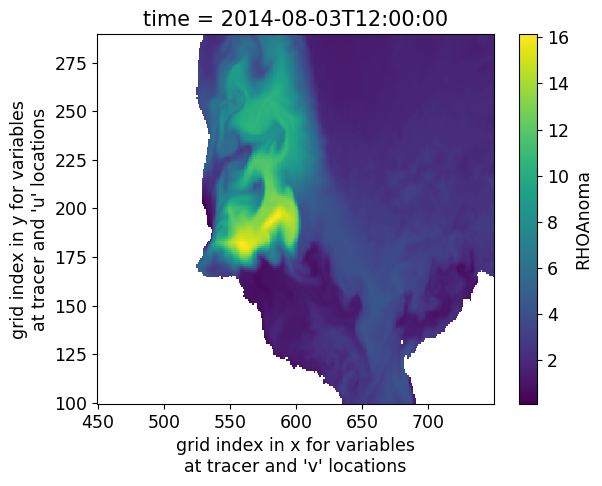

In [230]:
delta_rho20.isel(time=200).plot()

In [231]:
i_select = 540
j_select = 250
drho = delta_rho20.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sst = SST_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sic = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
time = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).time
ice_date = doy_to_date(2019, int(DOY_2019.sel(i=i_select,j=j_select)))

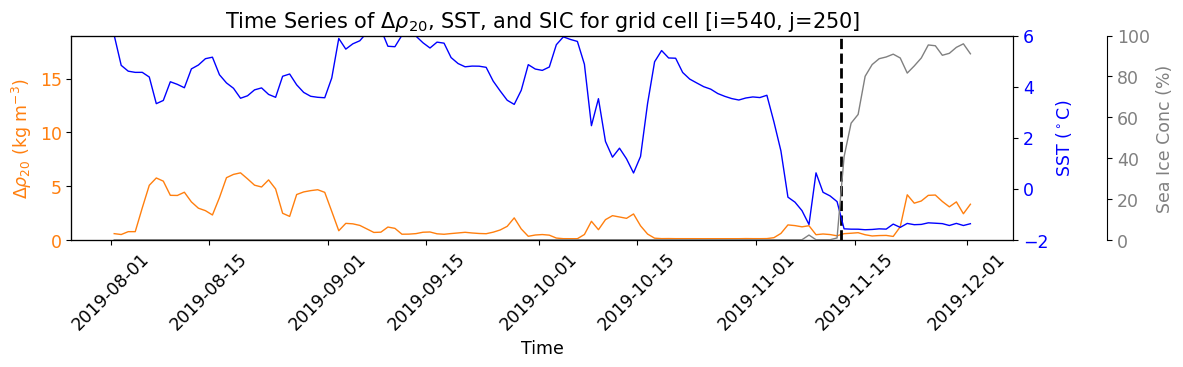

In [232]:
# Create a figure and axis
plt.rcParams.update({'font.size': 12.5})
fig, ax1 = plt.subplots(figsize=(12, 3),sharex=True)

# Plot drho on the primary y-axis
ax1.plot(time, drho, label="Delta rho", color="tab:orange",linewidth=1)
ax1.set_xlabel("Time")
ax1.set_ylabel(r"$\Delta\rho_{20}$ (kg m$^{-3}$)", color="tab:orange")
ax1.set_ylim(0,19)
ax1.tick_params(axis='y', labelcolor="tab:orange")

# add day when si>15%
ax1.axvline(x=ice_date,linestyle='dashed',linewidth=2,color='k')

# Create the first secondary y-axis for SST
ax2 = ax1.twinx()
ax2.plot(time, sst, label="SST", color="blue",linewidth=1)
ax2.set_ylabel(r"SST ($^\circ$C)", color="blue")
ax2.set_ylim(-2,6)
ax2.tick_params(axis='y', labelcolor="blue")

# Create a second secondary y-axis for SIC
ax3 = ax1.twinx()
ax3.spines["right"].set_position(('axes', 1.1)) # Offset the third y-axis
ax3.plot(time, sic, label="SIC", color="gray",linewidth=1)
ax3.set_ylabel("Sea Ice Conc (%)", color="gray")
ax3.set_ylim(0,100)
ax3.tick_params(axis='y', labelcolor="gray")

# Align the labels of all y-axes
fig.tight_layout()

for label in ax1.get_xticklabels():
    label.set_rotation(45)

# Show the plot
plt.title(f"Time Series of $\\Delta\\rho_{{20}}$, SST, and SIC for grid cell [i={i_select}, j={j_select}]")
plt.show()

In [233]:
i_select = 565
j_select = 180
drho = delta_rho20.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sst = SST_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sic = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
time = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).time
ice_date = doy_to_date(2019, int(DOY_2019.sel(i=i_select,j=j_select)))

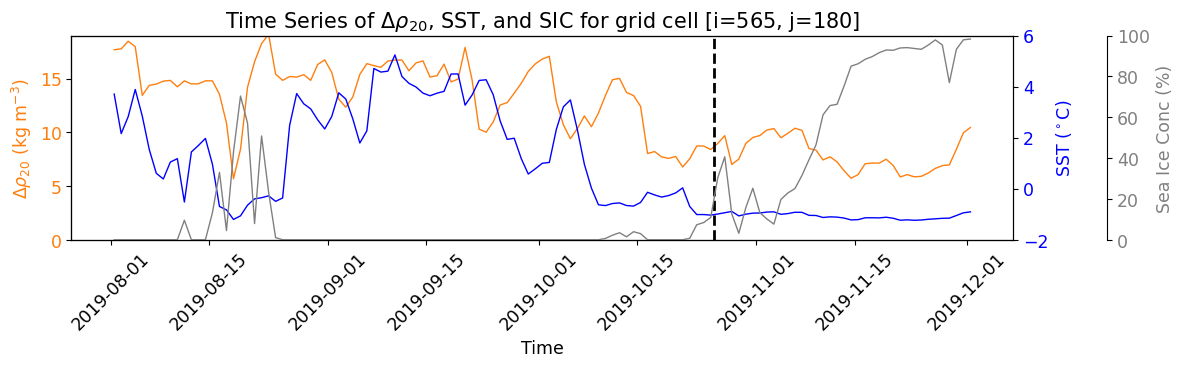

In [234]:
# Create a figure and axis
plt.rcParams.update({'font.size': 12.5})
fig, ax1 = plt.subplots(figsize=(12, 3),sharex=True)

# Plot drho on the primary y-axis
ax1.plot(time, drho, label="Delta rho", color="tab:orange",linewidth=1)
ax1.set_xlabel("Time")
ax1.set_ylabel(r"$\Delta\rho_{20}$ (kg m$^{-3}$)", color="tab:orange")
ax1.set_ylim(0,19)
ax1.tick_params(axis='y', labelcolor="tab:orange")

# add day when si>15%
ax1.axvline(x=ice_date,linestyle='dashed',linewidth=2,color='k')

# Create the first secondary y-axis for SST
ax2 = ax1.twinx()
ax2.plot(time, sst, label="SST", color="blue",linewidth=1)
ax2.set_ylabel(r"SST ($^\circ$C)", color="blue")
ax2.set_ylim(-2,6)
ax2.tick_params(axis='y', labelcolor="blue")

# Create a second secondary y-axis for SIC
ax3 = ax1.twinx()
ax3.spines["right"].set_position(('axes', 1.1)) # Offset the third y-axis
ax3.plot(time, sic, label="SIC", color="gray",linewidth=1)
ax3.set_ylabel("Sea Ice Conc (%)", color="gray")
ax3.set_ylim(0,100)
ax3.tick_params(axis='y', labelcolor="gray")

# Align the labels of all y-axes
fig.tight_layout()

for label in ax1.get_xticklabels():
    label.set_rotation(45)

# Show the plot
plt.title(f"Time Series of $\\Delta\\rho_{{20}}$, SST, and SIC for grid cell [i={i_select}, j={j_select}]")
plt.show()

In [235]:
i_select = 660
j_select = 120
drho = delta_rho20.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sst = SST_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
sic = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).values
time = SI_beaufort.sel(i=i_select,j=j_select).sel(time=slice('2019-08-01','2019-12-01')).time
ice_date = doy_to_date(2019, int(DOY_2019.sel(i=i_select,j=j_select)))

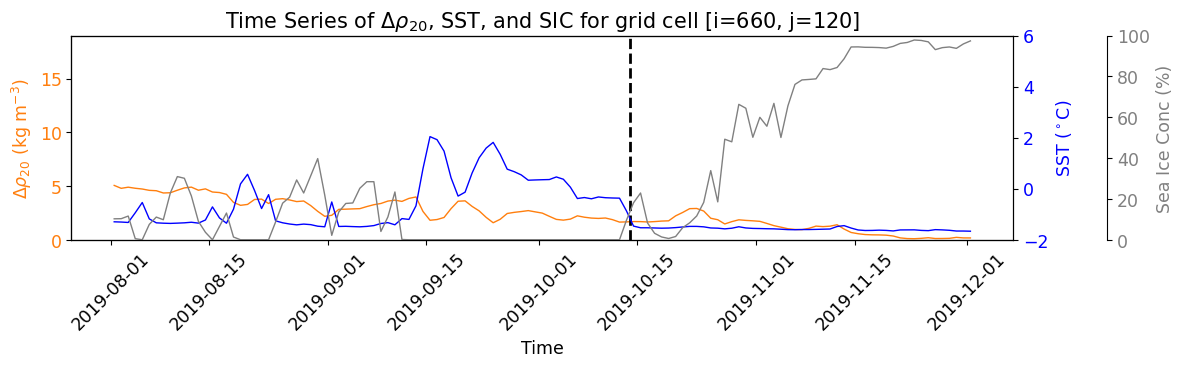

In [236]:
# Create a figure and axis
plt.rcParams.update({'font.size': 12.5})
fig, ax1 = plt.subplots(figsize=(12, 3),sharex=True)

# Plot drho on the primary y-axis
ax1.plot(time, drho, label="Delta rho", color="tab:orange",linewidth=1)
ax1.set_xlabel("Time")
ax1.set_ylabel(r"$\Delta\rho_{20}$ (kg m$^{-3}$)", color="tab:orange")
ax1.set_ylim(0,19)
ax1.tick_params(axis='y', labelcolor="tab:orange")

# add day when si>15%
ax1.axvline(x=ice_date,linestyle='dashed',linewidth=2,color='k')

# Create the first secondary y-axis for SST
ax2 = ax1.twinx()
ax2.plot(time, sst, label="SST", color="blue",linewidth=1)
ax2.set_ylabel(r"SST ($^\circ$C)", color="blue")
ax2.set_ylim(-2,6)
ax2.tick_params(axis='y', labelcolor="blue")

# Create a second secondary y-axis for SIC
ax3 = ax1.twinx()
ax3.spines["right"].set_position(('axes', 1.1)) # Offset the third y-axis
ax3.plot(time, sic, label="SIC", color="gray",linewidth=1)
ax3.set_ylabel("Sea Ice Conc (%)", color="gray")
ax3.set_ylim(0,100)
ax3.tick_params(axis='y', labelcolor="gray")

# Align the labels of all y-axes
fig.tight_layout()

for label in ax1.get_xticklabels():
    label.set_rotation(45)

# Show the plot
plt.title(f"Time Series of $\\Delta\\rho_{{20}}$, SST, and SIC for grid cell [i={i_select}, j={j_select}]")
plt.show()